# Практика по определению моделей в Keras

В каждом из заданий ниже, реализуйте модель, повторяющую архитектуру на приложенной картинке. При определении моделей, можете использовать как Sequential так и Functional API.

In [8]:
! pip install tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
import numpy as np

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
import numpy as np

In [11]:
import tensorflow as tf
print(tf.__version__)

2.19.0


## Задание 1

Реализуйте модель описанную ниже. Активацию последнего слоя сделайте "softmax".

<img src="https://drive.google.com/uc?export=view&id=1QCKcPlmguNNXPvUQnUaphcfOTWvQKzEW" width=200>
<img src="https://drive.google.com/uc?export=view&id=1r6DoTrn8Pe2RKuPT3RM9rR8Xc2X3WNVe" width=400>


Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer17 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer18 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer19 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279 (1.09 KB)

 Trainable params: 279 (1.09 KB)

 Non-trainable params: 0 (0.00 B)

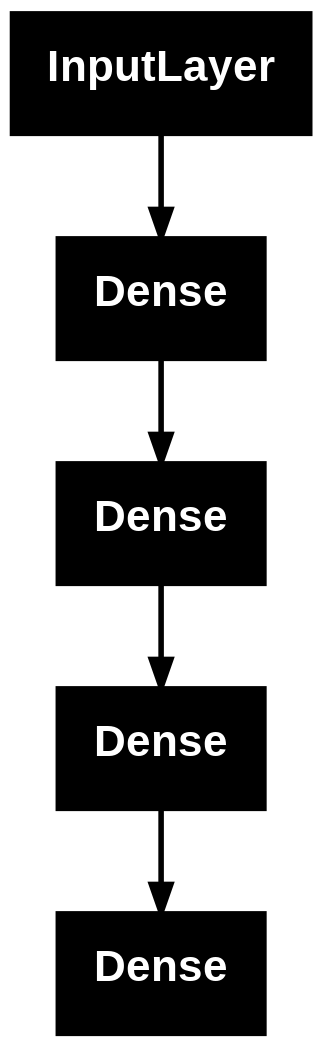

In [35]:
input_layer = tf.keras.layers.Input(shape=(10, ), name="Input")
l17 = Dense(4, name="Layer17") # определили первый слой
l17_output = l17(input_layer) # соеденили его с инпутом
l18_output = Dense(8, name="Layer18")(l17_output) # дальше будем определять чуть компактнее
l19_output = Dense(16, name="Layer19")(l18_output)
output = Dense(3, activation='softmax', name="Output")(l19_output) # выходной слой
model = tf.keras.Model(inputs=input_layer, outputs=output, name="my_model")


# <YOUR CODE ENDS HERE >
model.summary()
tf.keras.utils.plot_model(model, show_shapes=False)

In [36]:
output = model(np.ones((3, 10)))
assert np.allclose(output.numpy().sum(1),  np.ones(3)), "Did you forget softmax in the last layer?"
assert model.count_params() == 279, "Wrong params number"
print("Simple tests passed")

Simple tests passed


## Задание 2

Реализуйте модель описанную ниже.

<img src="https://lh3.googleusercontent.com/Aa_RCQNbksP9j27Br0kbq-Aj_yWHW3fofmaZj6jOm8xBLgWrEn60MbxVBkfZipLJ5mI3LAMC9wdhv08i76oKY6cQzUdYVHyRzLV4dZ8Yw-TIC6Y82gLe1zmdwzpX2JkFmo-nJy6YPLGiZuqkjKJlTdtHdFdDuIp_akK2fSMEMf85u3_3N-Gx6XSTxaQsCX5PL8aWlNeDl5rpHhmQYBTe1TR2-EDsAMgz4CLBMwyhVPJwjBR57WOBw14NPp6RrayuaPSltd9qbvQG2236WKqyL0w__y6tR6Vg7WMtUm4SKrPbTSUUyEEvU1hH6Z6yQpgyRRXecdupmTyx3FySqgERRVIqEb-JNoLppqzcaBEHDKdi0I7tQuuKXVyjSq5P02McLEwR7ej3dKVC8R3EsFDZV8uVLWJQSdpvInhp5d0fGb5u-UOfRuJ1X_4s2A6BJPbWbj4NyQAWPFem02A2Ya4CpzgDbMnjiAmlt_-JavcPCi7UALu6mH_RzPgNkzlrSqEMHpdBnVs6vhtEQGoZU1kxARvZxfBnbXTudg0IYjZ-LBKEfEFRwN3pbC3A9xnPS_-LRXcvAy45VSgH_JgPV4PpBFwo-xVg6O1RUhbOBuR8_a9OOyLd2zN8NaLO4e4bxq8pHD9mIXXBrxxCK76pjO5Vs2m03h-U7o6VTci3Fr9U5f2rF4ejP_7pNtSwfZ3RRA=w646-h220-no?authuser=0" width=400>
<img src="https://drive.google.com/uc?export=view&id=1vR3XfyYEpSmgEXZoLGY_FfWRwgOiefoj" width=300>


*Кстати, такая кострукция не лишена смысла -- в следующем модуле мы увидим как она помогла совершить прорыв в классификации изображений. Она носит название residual block*

Подсказка: на последнем слое используйте метод `Add()` класса layers, на вход которому нужно подать массик из `input_layer` и `l1_output`.


Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1 (Dense)          │ (None, 10)        │        110 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sumLayer (Add)      │ (None, 10)        │          0 │ input[0][0],      │
│                     │                   │            │ l1[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110 (440.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

Simple tests passed


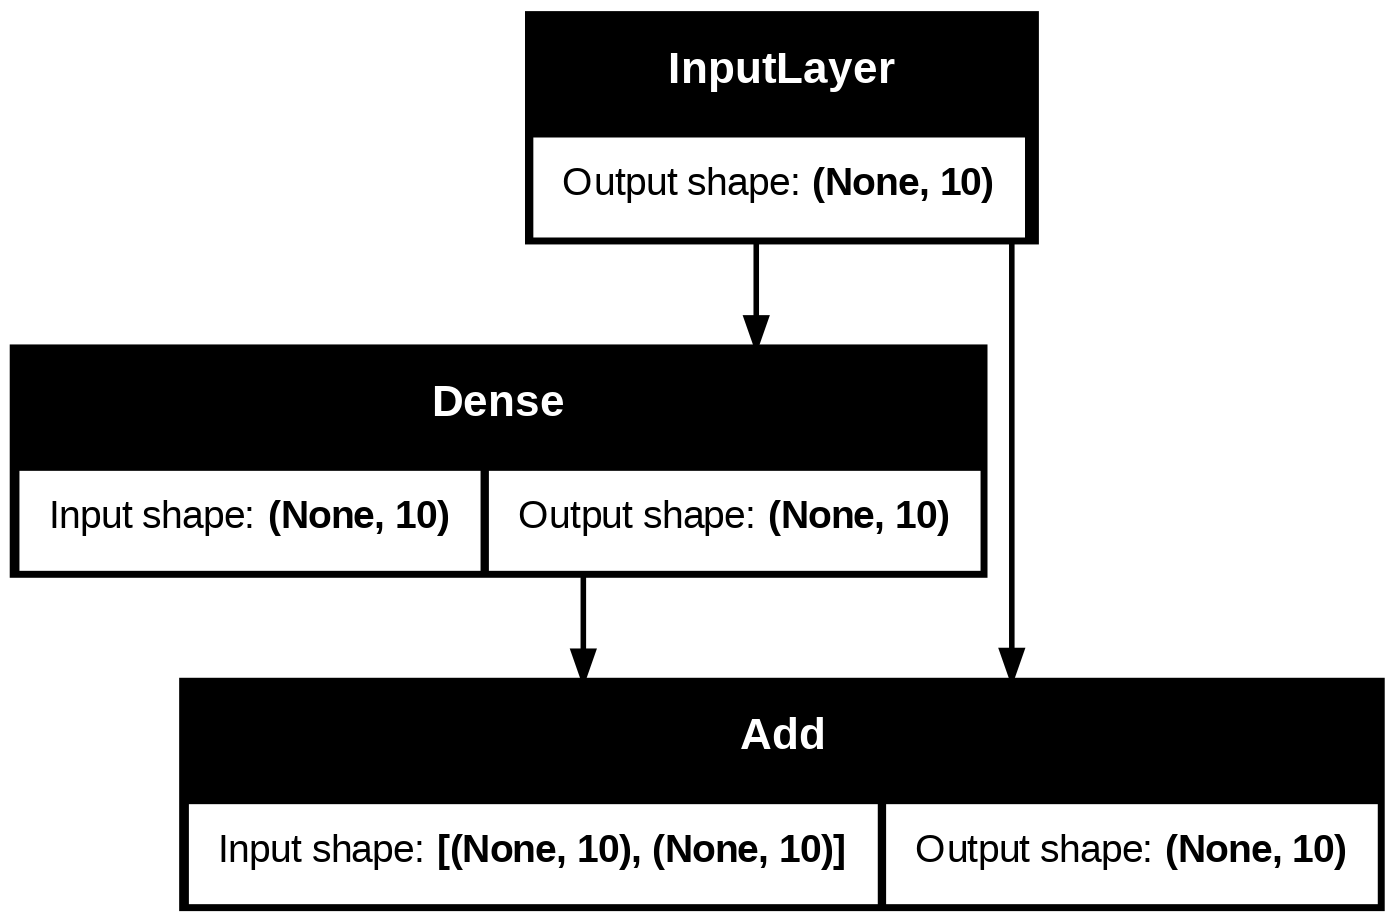

In [42]:
input_layer = tf.keras.layers.Input(shape = (10, ), name = "input")
l1 = Dense(10, name = "l1")
l1_output = l1(input_layer)

sum_output = tf.keras.layers.add([input_layer, l1_output], name="sumLayer")
output = Dense(10, name = "output")(sum_output)

model = tf.keras.Model(inputs=input_layer, outputs=sum_output, name = "my_model")


# <YOUR CODE ENDS HERE >
model.summary()
assert model.count_params() == 110, "Wrong params number"
print("Simple tests passed")
tf.keras.utils.plot_model(model, show_shapes=True)

## Задание 3

Реализуйте модель описанную ниже. Вам пригодится tf.keras.layers.Concatenate.

<img src="https://drive.google.com/uc?export=view&id=1LvsTd2a0HW-duuv3UyxCBLmERpqQQweU" width=450>
<img src="https://drive.google.com/uc?export=view&id=18IMatPWKG-0T9gisyJ_k465mospO_xow" width=400>


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1 (Dense)          │ (None, 10)        │        110 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2 (Dense)          │ (None, 10)        │        110 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l3 (Dense)          │ (None, 10)        │        110 │ l1[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l4 (Dense)          │ (None, 10)        │        110 │ l1[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l5 (Dense)          │ (None, 10)        │        110 │ l2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l6 (Dense)          │ (None, 10)        │        110 │ l2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_output       │ (None, 40)        │          0 │ l3[0][0],         │
│ (Concatenate)       │                   │            │ l4[0][0],         │
│                     │                   │            │ l5[0][0],         │
│                     │                   │            │ l6[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        123 │ concat_output[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 783 (3.06 KB)

 Trainable params: 783 (3.06 KB)

 Non-trainable params: 0 (0.00 B)

Simple tests passed


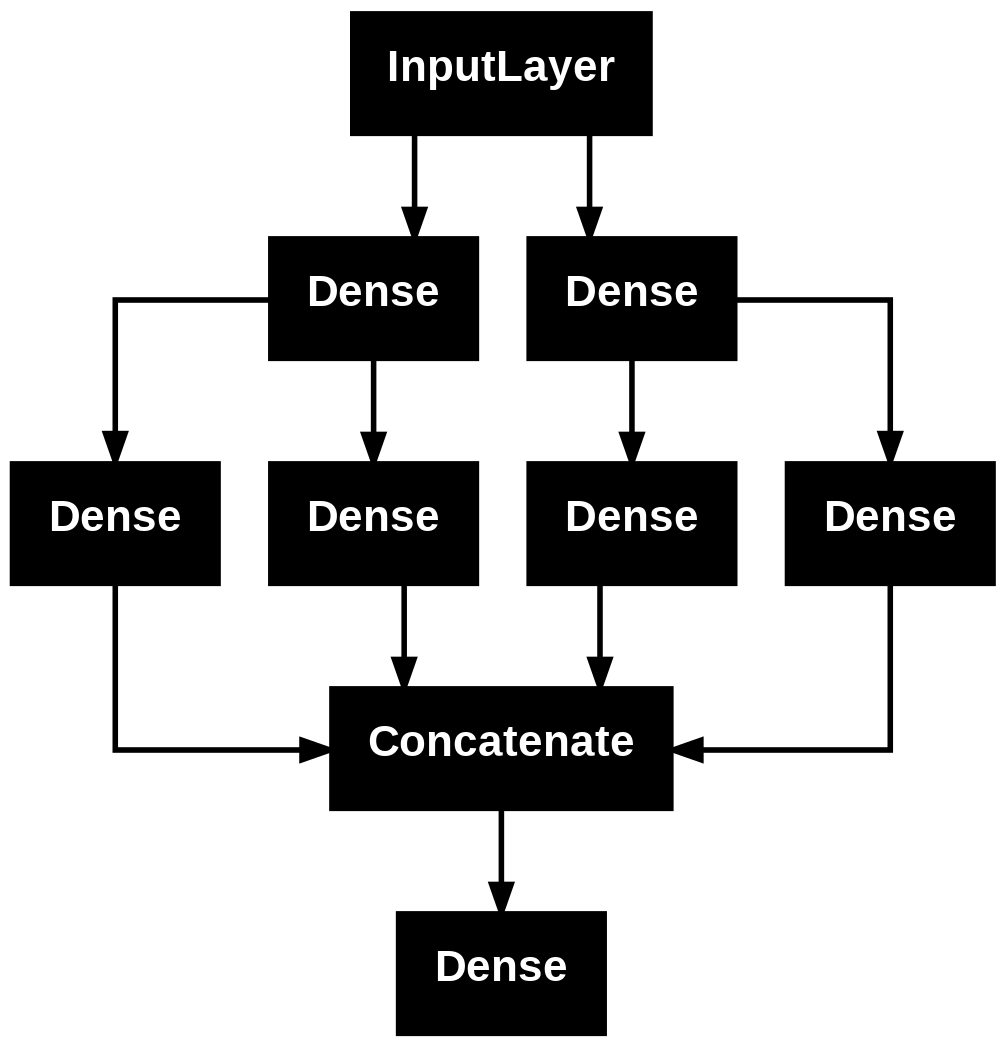

In [46]:
inputLayer = tf.keras.layers.Input(shape = (10, ), name = "input")
l1 = Dense(10, name = "l1")
l1_output = l1(inputLayer)

l2 = Dense(10, name = "l2")
l2_output = l2(inputLayer)

l3 = Dense(10, name = "l3")
l3_output = l3(l1_output)
l4 = Dense(10, name = "l4")
l4_output = l4(l1_output)

l5 = Dense(10, name = "l5")
l5_output = l5(l2_output)
l6 = Dense(10, name = "l6")
l6_output = l6(l2_output)

concat_output = tf.keras.layers.Concatenate(name = "concat_output")([l3_output, l4_output, l5_output, l6_output])

output = Dense(3, name = "output")(concat_output)

model = tf.keras.Model(inputs=inputLayer, outputs=output)















# <YOUR CODE ENDS HERE >

model.summary()
assert model.count_params() == 783, "Wrong params number"
print("Simple tests passed")
tf.keras.utils.plot_model(model, show_shapes=False)